# Laboratorio: Transformación de texto en embeddings con TensorFlow

**Objetivo:** comprender cómo un texto se transforma en representaciones numéricas (*embeddings*) y aplicar estas representaciones en un modelo de clasificación de texto.

En este notebook se realizan:
1. Preparación y exploración de datos.
2. Tokenización y creación de secuencias.
3. Construcción de una capa `Embedding`.
4. Entrenamiento de una red neuronal.
5. Evaluación mediante precisión y pérdida.
6. Predicciones sobre textos.
7. Análisis de resultados.

>


In [1]:
# 1. IMPORTACIÓN DE LIBRERÍAS
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("Versión de TensorFlow:", tf.__version__)


Versión de TensorFlow: 2.20.0


## 2. Dataset

Se utiliza el conjunto de datos **IMDB**, incluido en `tf.keras.datasets`. Contiene reseñas de películas etiquetadas como:
- `0`: sentimiento negativo
- `1`: sentimiento positivo

Para facilitar el experimento, se limita el vocabulario a 10.000 palabras y cada reseña se lleva a una longitud máxima de 200 tokens.


In [2]:
# 2. CARGA DEL DATASET IMDB
VOCAB_SIZE = 10000
MAX_LEN = 200

(train_data, train_labels), (test_data, test_labels) = tf.keras.datasets.imdb.load_data(
    num_words=VOCAB_SIZE
)

print("Ejemplos de entrenamiento:", len(train_data))
print("Ejemplos de prueba:", len(test_data))
print("Primera secuencia:", train_data[0][:20])
print("Primera etiqueta:", train_labels[0])


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Ejemplos de entrenamiento: 25000
Ejemplos de prueba: 25000
Primera secuencia: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
Primera etiqueta: 1


In [3]:
# 3. AJUSTE DE LONGITUD
train_data = tf.keras.utils.pad_sequences(
    train_data, maxlen=MAX_LEN, padding="post", truncating="post"
)

test_data = tf.keras.utils.pad_sequences(
    test_data, maxlen=MAX_LEN, padding="post", truncating="post"
)

print("Forma de train_data:", train_data.shape)
print("Forma de test_data:", test_data.shape)


Forma de train_data: (25000, 200)
Forma de test_data: (25000, 200)


## 3. ¿Qué significa tokenizar?

Una máquina no procesa directamente palabras como `"excellent"` o `"boring"`. Primero se asigna un número a cada palabra del vocabulario. De esta manera, una frase se representa como una secuencia de enteros.

Ejemplo conceptual:

`"excellent movie"` → `[245, 18]`

La secuencia numérica todavía **no es el embedding**. Es la entrada que posteriormente recibe la capa `Embedding`.


In [4]:
# 4. INSPECCIÓN DEL VOCABULARIO
word_index = tf.keras.datasets.imdb.get_word_index()

# Algunas palabras y sus índices
for palabra in ["excellent", "movie", "boring", "good"]:
    print(palabra, "->", word_index.get(palabra, "no encontrada"))


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
excellent -> 318
movie -> 17
boring -> 354
good -> 49


## 4. Capa de Embedding

La capa `Embedding` aprende un vector para cada token del vocabulario.

Si usamos `EMBEDDING_DIM = 32`, cada palabra queda representada mediante un vector de 32 números:

`token → [x1, x2, x3, ..., x32]`

Durante el entrenamiento, estos vectores se ajustan para ayudar al modelo a resolver la tarea de clasificación.


In [5]:
# 5. MODELO CON EMBEDDINGS
EMBEDDING_DIM = 32

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True,
        name="embedding"
    ),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 5. Entrenamiento

Se divide una parte de los datos de entrenamiento para validación. La métrica principal será `accuracy`, mientras que `loss` permite observar el error del modelo.


In [6]:
# 6. ENTRENAMIENTO
history = model.fit(
    train_data,
    train_labels,
    validation_split=0.2,
    epochs=5,
    batch_size=128,
    verbose=1
)


Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6844 - loss: 0.6194 - val_accuracy: 0.8262 - val_loss: 0.4742
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8478 - loss: 0.3847 - val_accuracy: 0.8588 - val_loss: 0.3395
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8866 - loss: 0.2887 - val_accuracy: 0.8746 - val_loss: 0.3053
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9061 - loss: 0.2449 - val_accuracy: 0.8764 - val_loss: 0.3029
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9197 - loss: 0.2123 - val_accuracy: 0.8764 - val_loss: 0.3078


In [7]:
# 7. EVALUACIÓN
test_loss, test_accuracy = model.evaluate(test_data, test_labels, verbose=0)

print(f"Pérdida en prueba: {test_loss:.4f}")
print(f"Precisión en prueba: {test_accuracy:.4f}")
print(f"Precisión porcentual: {test_accuracy*100:.2f}%")


Pérdida en prueba: 0.3306
Precisión en prueba: 0.8609
Precisión porcentual: 86.09%


## 6. Visualización de resultados

Las gráficas permiten comprobar si el modelo aprende y si existe una diferencia importante entre entrenamiento y validación.


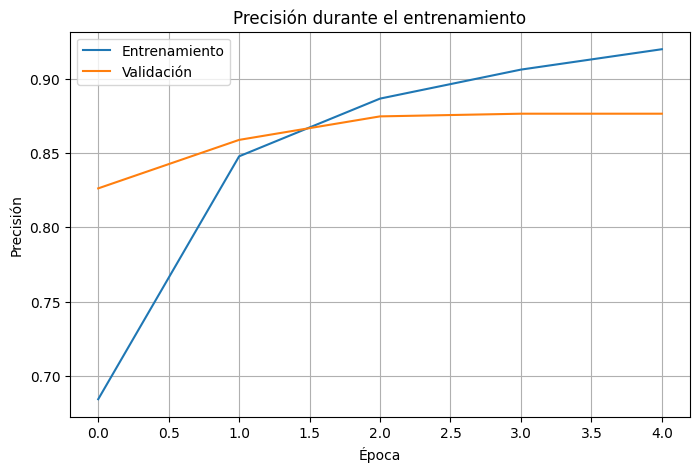

In [8]:
# 8. GRÁFICA DE PRECISIÓN
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Entrenamiento")
plt.plot(history.history["val_accuracy"], label="Validación")
plt.xlabel("Época")
plt.ylabel("Precisión")
plt.title("Precisión durante el entrenamiento")
plt.legend()
plt.grid(True)
plt.show()


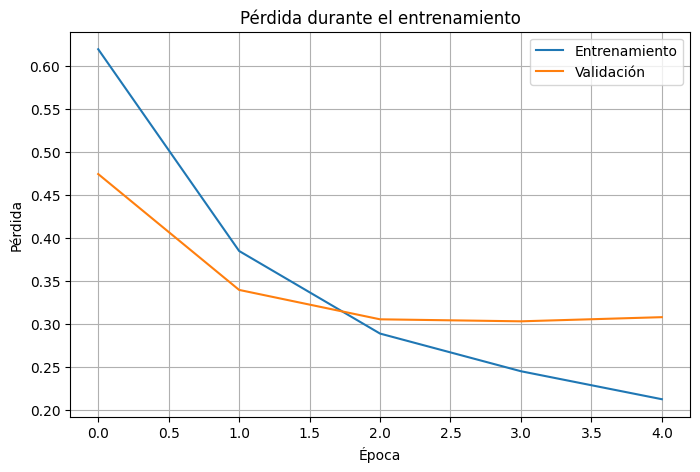

In [9]:
# 9. GRÁFICA DE PÉRDIDA
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Entrenamiento")
plt.plot(history.history["val_loss"], label="Validación")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Pérdida durante el entrenamiento")
plt.legend()
plt.grid(True)
plt.show()


## 7. Inspección de los embeddings

Después del entrenamiento podemos acceder a los pesos de la capa `Embedding`. Cada fila corresponde al vector aprendido para un token.


In [10]:
# 10. EXTRAER MATRIZ DE EMBEDDINGS
embedding_layer = model.get_layer("embedding")
embedding_matrix = embedding_layer.get_weights()[0]

print("Forma de la matriz de embeddings:", embedding_matrix.shape)
print("Vector del token 10:", embedding_matrix[10])


Forma de la matriz de embeddings: (10000, 32)
Vector del token 10: [ 0.14077517 -0.04443297  0.07657801  0.09988371 -0.05182214  0.05679051
 -0.09898183  0.155729   -0.04257704  0.0147504  -0.01917131 -0.07183339
 -0.24681585  0.01423263 -0.09373114 -0.00148484 -0.08603424 -0.16441259
  0.03901538  0.01111747  0.06195519  0.11965525  0.06293062 -0.37350664
 -0.07397969 -0.15959094  0.00347824 -0.0914591   0.17462228  0.0257629
 -0.01411662 -0.25197485]


In [11]:
# 11. MAGNITUD DE ALGUNOS VECTORES
normas = np.linalg.norm(embedding_matrix, axis=1)

print("Norma mínima:", normas.min())
print("Norma máxima:", normas.max())
print("Norma promedio:", normas.mean())


Norma mínima: 0.12591706
Norma máxima: 5.1082172
Norma promedio: 0.5018248


## 8. Predicción de nuevas reseñas

Para probar el modelo con texto nuevo se debe utilizar el mismo vocabulario y la misma transformación que se utilizó durante el entrenamiento.


In [19]:
# 12. FUNCIONES PARA CONVERTIR TEXTO A SECUENCIA
reverse_word_index = {value: key for key, value in word_index.items()}

def texto_a_secuencia(texto):
    palabras = texto.lower().split()
    secuencia = []
    for palabra in palabras:
        palabra = palabra.strip(".,!?;:'\"()[]")

        # OBTENER EL ÍNDICE Y SUMAR EL DESFASE DE KERAS (3)
        indice = word_index.get(palabra)
        if indice is None or (indice + 3) >= VOCAB_SIZE:
            indice = 2  # token <UNK>
        else:
            indice = indice + 3

        secuencia.append(indice)

    return tf.keras.utils.pad_sequences(
        [secuencia], maxlen=MAX_LEN, padding="post", truncating="post"
    )

def predecir(texto):
    secuencia = texto_a_secuencia(texto)
    probabilidad = float(model.predict(secuencia, verbose=0)[0][0])

    # Keras IMDB: 1.0 es POSITIVO y 0.0 es NEGATIVO
    etiqueta = "positivo" if probabilidad >= 0.5 else "negativo"
    return etiqueta, probabilidad


In [20]:
# 13. PRUEBAS
ejemplos = [
    "excellent movie good acting",
    "boring bad movie waste time",
    "good story excellent",
    "bad boring terrible"
]

for texto in ejemplos:
    etiqueta, probabilidad = predecir(texto)
    print(f"Texto: {texto}")
    print(f"Predicción: {etiqueta} | Probabilidad positiva: {probabilidad:.3f}")
    print("-" * 60)


Texto: excellent movie good acting
Predicción: positivo | Probabilidad positiva: 1.000
------------------------------------------------------------
Texto: boring bad movie waste time
Predicción: negativo | Probabilidad positiva: 0.000
------------------------------------------------------------
Texto: good story excellent
Predicción: positivo | Probabilidad positiva: 1.000
------------------------------------------------------------
Texto: bad boring terrible
Predicción: negativo | Probabilidad positiva: 0.000
------------------------------------------------------------


## 9. Análisis de resultados

Llegar a un 86% de acierto muestra que

las representaciones creadas por la capa de embeddings fueron bastante

efectivas. La red logró identificar combinaciones de palabras clave que definen

si un comentario es positivo o negativo.

El valor de pérdida (0.3306) ayuda a

entender que, más allá de atinarle a la categoría final, la red lo hace con un

nivel razonable de certeza. De todas formas, hay que tener claro que el modelo

no "entiende" la película ni el texto como lo haría una persona. Hay

limitaciones claras: el sarcasmo, las frases con doble sentido o las reseñas

mixtas (donde hablan bien de los actores pero mal del guion) son situaciones

que confunden fácilmente a este tipo de arquitectura.

El resultado final depende

directamente de las decisiones tomadas: el límite de 10,000 palabras, el corte

a 200 tokens y las 5 épocas de entrenamiento. Aun así, para ser un experimento

inicial, demuestra claramente el poder de los embeddings en NLP.




## 10. Conclusiones


• Este laboratorio me ayudó a entender en la práctica cómo se conecta el texto con los
modelos matemáticos a través de tokens y vectores.
• La capa de Embedding demostró ser una pieza fundamental, ya que transformó números
planos en vectores capaces de capturar el contexto de las reseñas.
• Lograr una precisión del 86.09% confirma que el modelo aprendió a generalizar
correctamente con datos que nunca vio en la fase de entrenamiento.
• Analizar los resultados va más allá de ver si el código corre; implica comprender las
métricas, identificar en qué casos el modelo puede fallar y evaluar el alcance real de la
solución.